In [1]:
!pip install pandas scikit-learn joblib

In [2]:
import pandas as pd

df = pd.read_csv("CBTweets.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (47692, 2)

Columns:
Index(['tweet_text', 'cyberbullying_type'], dtype='object')

First 5 rows:


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [3]:
import re
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Clean the tweets
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


df["clean_text"] = df["tweet_text"].apply(clean_text)


# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["cyberbullying_type"],
    test_size=0.2,
    random_state=42,
    stratify=df["cyberbullying_type"]
)


# Convert words into numbers using TF-IDF
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)


# Create and train the AI model
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)


# Test the model
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("================================")
print("CYBERBULLYING DETECTOR")
print("================================")
print(f"\nAccuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



joblib.dump(model, "cyberbullying_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("\n✅ MODEL TRAINED AND SAVED!")

CYBERBULLYING DETECTOR

Accuracy: 82.20%

Classification Report:
                     precision    recall  f1-score   support

                age       0.97      0.97      0.97      1598
          ethnicity       0.97      0.96      0.96      1592
             gender       0.91      0.83      0.87      1595
  not_cyberbullying       0.59      0.53      0.56      1589
other_cyberbullying       0.57      0.71      0.63      1565
           religion       0.96      0.94      0.95      1600

           accuracy                           0.82      9539
          macro avg       0.83      0.82      0.82      9539
       weighted avg       0.83      0.82      0.82      9539


✅ MODEL TRAINED AND SAVED!


In [5]:
def predict_cyberbullying(tweet):
    cleaned = clean_text(tweet)

    # Convert text into TF-IDF
    tweet_vector = vectorizer.transform([cleaned])

    # Make prediction
    prediction = model.predict(tweet_vector)[0]

    probabilities = model.predict_proba(tweet_vector)[0]
    confidence = max(probabilities) * 100

    print("================================")
    print("CYBERBULLYING DETECTOR")
    print("================================")
    print(f"\nTweet: {tweet}")
    print(f"\nPrediction: {prediction}")
    print(f"Confidence: {confidence:.2f}%")

    if prediction == "not_cyberbullying":
        print("\n✅ This tweet is classified as NOT cyberbullying.")
    else:
        print("\n⚠️ This tweet is classified as CYBERBULLYING.")
        print(f"Category: {prediction}")


predict_cyberbullying("I hate u")

CYBERBULLYING DETECTOR

Tweet: I hate u

Prediction: other_cyberbullying
Confidence: 60.57%

⚠️ This tweet is classified as CYBERBULLYING.
Category: other_cyberbullying


In [7]:
import ipywidgets as widgets
from IPython.display import display, clear_output

text_box = widgets.Textarea(
    placeholder="Type a tweet/comment here...",
    description="Comment:",
    layout=widgets.Layout(width="80%", height="100px")
)

button = widgets.Button(description="Detect Cyberbullying")
output = widgets.Output()

def detect(b):
    with output:
        clear_output()

        tweet = text_box.value

        if not tweet.strip():
            print("Please enter a comment.")
            return

        cleaned = clean_text(tweet)
        vector = vectorizer.transform([cleaned])

        prediction = model.predict(vector)[0]
        confidence = max(model.predict_proba(vector)[0]) * 100

        print("🔍 RESULT")
        print("-------------------------")

        if prediction == "not_cyberbullying":
            print("✅ NOT CYBERBULLYING")
        else:
            print("⚠️ CYBERBULLYING DETECTED")
            print(f"Category: {prediction}")

        print(f"Confidence: {confidence:.2f}%")

button.on_click(detect)

display(text_box)
display(button)
display(output)

Textarea(value='', description='Comment:', layout=Layout(height='100px', width='80%'), placeholder='Type a twe…

Button(description='Detect Cyberbullying', style=ButtonStyle())

Output()

🔍 RESULT
-------------------------
✅ NOT CYBERBULLYING
Confidence: 41.76%


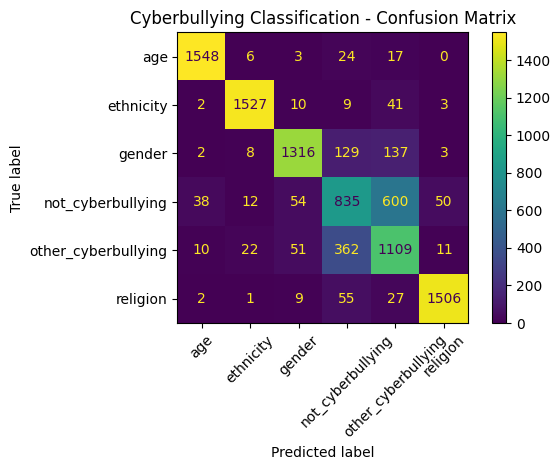

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.title("Cyberbullying Classification - Confusion Matrix")
plt.tight_layout()
plt.show()